In [ ]:
# Constants and Intermediate Variables

from math import exp

# n refers to potassium
# m refers to sodium activation gate
# h refers to sodium inactivation gate

# alpha = rate of opening for the specific gate, whether potassium or sodium

def alpha_n(V):
    return (0.01 * (10 - V)) / (exp(0.1 * (10 - V)) - 1) 

def alpha_m(V):
    return (0.1 * (25 - V))/(exp(0.1 * (25 - V)) - 1)

def alpha_h(V):
    return 0.07 * exp(-V / 20)

# beta = rate of closing

def beta_n(V):
    return 0.125 * exp(-V/80)

def beta_m(V):
    return 4 * exp(-V/18)

def beta_h(V):
    return 1 / (exp(0.1* (30-V)) + 1)

# Conductance functions for each channel.
# Max values were determined experimentally

def g_Na(m, h):
    max_sodium_conductance = 120
    return max_sodium_conductance * m**3 * h

def g_K(n):
    max_potassium_conductance = 36
    return max_potassium_conductance * n ** 4

def g_L():
    return 0.3 # leakage conductance

# Current functions

def I_Na(V, m, h):
    sodium_equilibrium_voltage = 115
    return g_Na(m, h) * (V - sodium_equilibrium_voltage)

def I_K(V,n):
    potassium_equilibrium_voltage = -12
    return g_K(n) * (V - potassium_equilibrium_voltage)

def I_L(V):
    leakage_equilibrium_voltage = 10.6
    return g_L() * (V - leakage_equilibrium_voltage)

def s(t): #stimulus function. This is when we are choosing to stimulate it
    intervals = [(10,11),(20,21),(30,40),(50,51),(53,54), (56,57),(59,60),(62,63),(65,66)]
    for a, b in intervals:
        if a <= t <= b:
            return 150
    return 0

In [27]:
# 4 main differentials and initial points

from multi_var_euler_estimator import EulerEstimator

# change in voltage
def dV_dt(t, state):
    C = 1 # membrane capacitance.
    return (1/C) * (s(t) - I_Na(state['V'], state['m'], state['h']) - I_K(state['V'], state['n']) - I_L(state['V']))

# changes in coefficients that represent probability that gates are open
def dn_dt(t,state):
    return alpha_n(state['V']) * (1 - state['n']) - beta_n(state['V']) * state['n']

def dm_dt(t,state):
    return alpha_m(state['V']) * (1 - state['m']) - beta_m(state['V']) * state['m']

def dh_dt(t,state):
    return alpha_h(state['V']) * (1 - state['h']) - beta_h(state['V']) * state['h']

derivatives = {'V': dV_dt, 'n': dn_dt, 'm':dm_dt, 'h':dh_dt}
euler = EulerEstimator(derivatives)

n_initial = alpha_n(0) / (alpha_n(0) + beta_n(0))
m_initial = alpha_m(0) / (alpha_m(0) + beta_m(0))
h_initial = alpha_h(0) / (alpha_h(0) + beta_h(0))

initial_state = {'V': 0, 'n': n_initial, 'm': m_initial, 'h': h_initial} 
initial_point = (0, initial_state)

values = euler.estimate_points(initial_point, step_size= 0.01, num_steps= 8000)


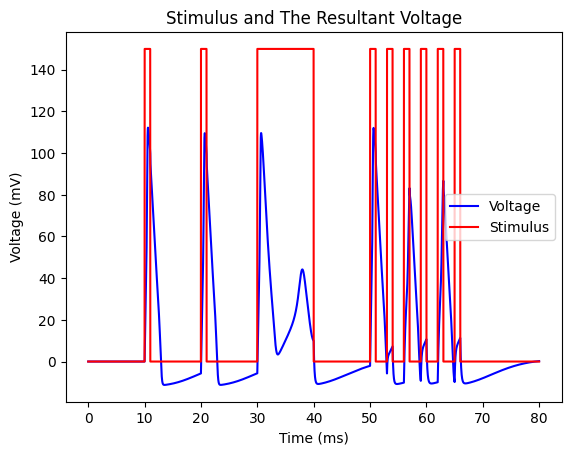

In [28]:
import matplotlib.pyplot as plt

x_values, y_values = zip(*values)

stimulus_values = [s(t) for t in x_values]
voltage_values = [state['V'] for state in y_values]

plt.plot(x_values, voltage_values, 'b-', label='Voltage')
plt.plot(x_values, stimulus_values, 'r-', label='Stimulus')

plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title("Stimulus and The Resultant Voltage")
plt.legend()
plt.show()

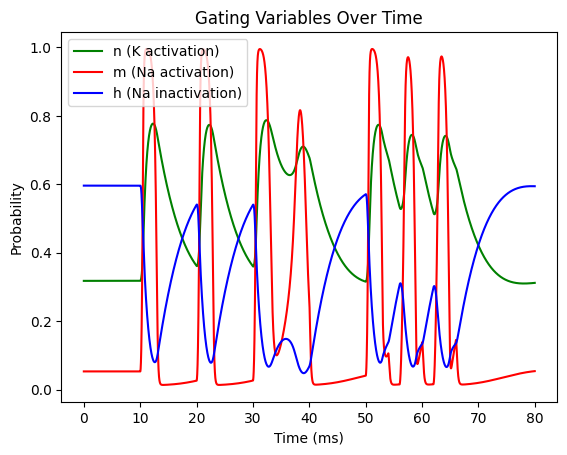

In [ ]:
# n, m, h variables plotted

n_values = [state['n'] for state in y_values]
m_values = [state['m'] for state in y_values]
h_values = [state['h'] for state in y_values]

plt.plot(x_values, n_values, 'g-', label='n (K activation)')
plt.plot(x_values, m_values, 'r-', label='m (Na activation)')
plt.plot(x_values, h_values, 'b-', label='h (Na inactivation)')

plt.xlabel('Time (ms)')
plt.ylabel('Probability')
plt.title('Gating Variables Over Time')
plt.legend()
plt.show()